### QUESTION 13: Data Understanding and Preprocessing:
- Use the provided helper code for loading and pre-processing Web10k data.
- Print out the number of unique queries in total and show distribution of relevance labels.

In [6]:
!!pip install lightgbm

['Requirement already satisfied: lightgbm in /Users/tilboon/opt/anaconda3/envs/ece219/lib/python3.10/site-packages (4.6.0)',
 'Requirement already satisfied: numpy>=1.17.0 in /Users/tilboon/opt/anaconda3/envs/ece219/lib/python3.10/site-packages (from lightgbm) (2.2.2)',
 'Requirement already satisfied: scipy in /Users/tilboon/opt/anaconda3/envs/ece219/lib/python3.10/site-packages (from lightgbm) (1.15.1)']

In [7]:
from sklearn.datasets import load_svmlight_file
from sklearn.metrics import ndcg_score
import numpy as np
import lightgbm as lgb

# Load the dataset for one fold
def load_one_fole(data_path):
    X_train, y_train, qid_train = load_svmlight_file(str(data_path + 'train.txt'), query_id=True)
    X_test, y_test, qid_test = load_svmlight_file(str(data_path + 'test.txt'), query_id=True)
    y_train = y_train.astype(int)
    y_test = y_test.astype(int)
    _, group_train = np.unique(qid_train, return_counts=True)
    _, group_test = np.unique(qid_test, return_counts=True)
    return X_train, y_train, qid_train, group_train, X_test, y_test, qid_test, group_test

def ndcg_single_query(y_score, y_true, k):
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order[:k])

    gain = 2 ** y_true - 1

    discounts = np.log2(np.arange(len(y_true)) + 2)
    return np.sum(gain / discounts)

# calculate NDCG score given a trained model 
def compute_ndcg_all(model, X_test, y_test, qids_test, k=10):
    unique_qids = np.unique(qids_test)
    ndcg_ = list()
    for i, qid in enumerate(unique_qids):
        y = y_test[qids_test == qid]

        if np.sum(y) == 0:
            continue

        p = model.predict(X_test[qids_test == qid])

        idcg = ndcg_single_query(y, y, k=k)
        ndcg_.append(ndcg_single_query(p, y, k=k) / idcg)
    return np.mean(ndcg_)

# get importance of features
def get_feature_importance(model, importance_type='gain'):
    return model.booster_.feature_importance(importance_type=importance_type)

Unique queries in Fold 1: 8000
Updated total unique queries 1: 8000
Unique queries in Fold 2: 8000
Updated total unique queries 2: 10000
Unique queries in Fold 3: 8000
Updated total unique queries 3: 10000
Unique queries in Fold 4: 8000
Updated total unique queries 4: 10000
Unique queries in Fold 5: 8000
Updated total unique queries 5: 10000

Total number of unique queries across all folds: 10000


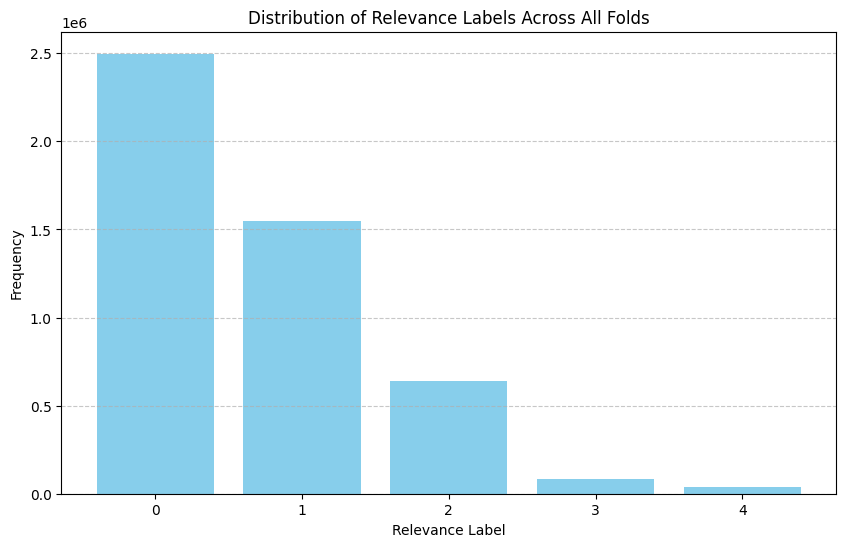

In [ ]:
import matplotlib.pyplot as plt

dataset_path = './MSLR-WEB10K/'  # path to the dataset

total_unique_queries = set()  # Changed from int to set for unique query tracking
total_label_counts = np.zeros(5, dtype=int)  # Assuming relevance labels 0 to 4

# load and preprocess the dataset
for fold in range(1, 6):
    X_train, y_train, qid_train, group_train, X_test, y_test, qid_test, group_test = load_one_fole(dataset_path + 'Fold{}/'.format(fold))
    
     # Unique queries per fold
    unique_queries = set(np.concatenate((qid_train, qid_test)))
    print(f"Unique queries in Fold {fold}: {len(unique_queries)}")
    total_unique_queries.update(unique_queries)
    print(f"Updated total unique queries {fold}: {len(total_unique_queries)}")
    
    # Count relevance labels for training and test sets
    fold_labels = np.concatenate((y_train, y_test))
    fold_label_counts = np.bincount(fold_labels.astype(int), minlength=5)
    total_label_counts += fold_label_counts

print(f"\nTotal number of unique queries across all folds: {len(total_unique_queries)}")

# Plot results
plt.figure(figsize=(10, 6))
plt.bar(range(5), total_label_counts, color='skyblue')
plt.xlabel('Relevance Label')
plt.ylabel('Frequency')
plt.title('Distribution of Relevance Labels Across All Folds')
plt.xticks(range(5))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### QUESTION 14: LightGBM Model Training:
For each of the five provided folds, train a LightGBM model using the ’lambdarank’ objective. After
training, evaluate and report the model’s performance on the test set using nDCG@3, nDCG@5 and
nDCG@10.

In [14]:
# Code for question 14
dataset_path = './MSLR-WEB10K/'  # path to the dataset

results = []
# load, preprocess, train, and evaluate the dataset
for fold in range(1, 6):
    X_train, y_train, qid_train, group_train, X_test, y_test, qid_test, group_test = load_one_fole(dataset_path + 'Fold{}/'.format(fold))

    # LightGBM parameters
    params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [3, 5, 10]
    }

     # Prepare datasets
    train_data_fold = lgb.Dataset(X_train, label=y_train, group=group_train)
    test_data_fold = lgb.Dataset(X_test, label=y_test, group=group_test, reference=train_data_fold)

    # Train the model
    model = lgb.train(params, train_data_fold, valid_sets=[test_data_fold])

    # Evaluate the model for nDCG@3, nDCG@5, nDCG@10
    ndcg_3 = compute_ndcg_all(model, X_test, y_test, qid_test, k=3)
    ndcg_5 = compute_ndcg_all(model, X_test, y_test, qid_test, k=5)
    ndcg_10 = compute_ndcg_all(model, X_test, y_test, qid_test, k=10)

    # Store results
    results.append({'fold': fold, 'ndcg@3': ndcg_3, 'ndcg@5': ndcg_5, 'ndcg@10': ndcg_10})

    # Print results for this fold
    print(f"Fold {fold} Results: nDCG@3: {ndcg_3:.4f}, nDCG@5: {ndcg_5:.4f}, nDCG@10: {ndcg_10:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.101412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25637
[LightGBM] [Info] Number of data points in the train set: 723412, number of used features: 136
Fold 1 Results: nDCG@3: 0.4567, nDCG@5: 0.4633, nDCG@10: 0.4830
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.152484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25623
[LightGBM] [Info] Number of data points in the train set: 716683, number of used features: 136
Fold 2 Results: nDCG@3: 0.4537, nDCG@5: 0.4572, nDCG@10: 0.4767
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.137401 seconds.
You can set `force_row_wise=true` to remove the overhead

#### Q14 Answer Summary:
- Fold 1 Results: nDCG@3: 0.4567, nDCG@5: 0.4633, nDCG@10: 0.4830
- Fold 2 Results: nDCG@3: 0.4537, nDCG@5: 0.4572, nDCG@10: 0.4767
- Fold 3 Results: nDCG@3: 0.4491, nDCG@5: 0.4584, nDCG@10: 0.4759
- Fold 4 Results: nDCG@3: 0.4611, nDCG@5: 0.4663, nDCG@10: 0.4878
- Fold 5 Results: nDCG@3: 0.4695, nDCG@5: 0.4714, nDCG@10: 0.4903

### QUESTION 15: Result Analysis and Interpretation:
For each of the five provided folds, list top 5 most important features of the model based on
the importance score. Please use model.booster .feature importance(importance type=’gain’) as
demonstrated here for retrieving importance score per feature. You can also find helper code in the
provided notebook.

In [15]:
# Code for question 15
dataset_path = './MSLR-WEB10K/'  # path to the dataset

# load, preprocess, train, evaluate, and extract top 5 important features of the dataset for each fole
for fold in range(1, 6):
    X_train, y_train, qid_train, group_train, X_test, y_test, qid_test, group_test = load_one_fole(dataset_path + 'Fold{}/'.format(fold))

    # LightGBM parameters
    params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [3, 5, 10]
    }

     # Prepare datasets
    train_data_fold = lgb.Dataset(X_train, label=y_train, group=group_train)
    test_data_fold = lgb.Dataset(X_test, label=y_test, group=group_test, reference=train_data_fold)

    # Train the model
    model = lgb.train(params, train_data_fold, valid_sets=[test_data_fold])

    # Get feature importance
    feature_importance = model.feature_importance(importance_type="gain")

    # Ranking top 5 most important features based on importance score
    top_features_indices = np.argsort(feature_importance)[::-1][:5]
    top_features = [f"Feature {idx + 1}" for idx in top_features_indices]
    
    print(f"\nTop 5 important features for Fold {fold}:")
    for feature in top_features:
        print(feature)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25637
[LightGBM] [Info] Number of data points in the train set: 723412, number of used features: 136

Top 5 important features for Fold 1:
Feature 134
Feature 8
Feature 108
Feature 55
Feature 130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.162653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25623
[LightGBM] [Info] Number of data points in the train set: 716683, number of used features: 136

Top 5 important features for Fold 2:
Feature 134
Feature 8
Feature 55
Feature 108
Feature 130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.097811 sec

#### Q15 Answer Summary:
Top 5 important features for Fold 1:
- Feature 134
- Feature 8
- Feature 108
- Feature 55
- Feature 130

Top 5 important features for Fold 2:
- Feature 134
- Feature 8
- Feature 55
- Feature 108
- Feature 130

Top 5 important features for Fold 3:
- Feature 134
- Feature 55
- Feature 108
- Feature 130
- Feature 8

Top 5 important features for Fold 4:
- Feature 134
- Feature 8
- Feature 55
- Feature 130
- Feature 129

Top 5 important features for Fold 5:
- Feature 134
- Feature 8
- Feature 55
- Feature 108
- Feature 130

### QUESTION 16.1: Experiments with Subset of Features:
For each of the five provided folds:

- Remove the top 20 most important features according to the computed importance score in
the question 15. Then train a new LightGBM model on the resulted 116 dimensional query-
url data. Evaluate the performance of this new model on the test set using nDCG. Does
the outcome align with your expectations? If not, please share your hypothesis regarding the
potential reasons for this discrepancy.

In [17]:
# Code for question 16.1
dataset_path = './MSLR-WEB10K/'  # path to the dataset

# load, preprocess, train, evaluate, and extract top 5 important features of the dataset for each fole
for fold in range(1, 6):
    X_train, y_train, qid_train, group_train, X_test, y_test, qid_test, group_test = load_one_fole(dataset_path + 'Fold{}/'.format(fold))

    # LightGBM parameters
    params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [3, 5, 10]
    }

    # Prepare datasets
    train_data_fold = lgb.Dataset(X_train, label=y_train, group=group_train)
    test_data_fold = lgb.Dataset(X_test, label=y_test, group=group_test, reference=train_data_fold)

    # Train the model
    model = lgb.train(params, train_data_fold, valid_sets=[test_data_fold])

    # Get feature importance
    feature_importance = model.feature_importance(importance_type="gain")

    # Ranking top 20 most important features based on importance score
    top_20 = np.argsort(feature_importance)[::-1][:20]

    # New training and testing data without the top 20 features
    X_train_top_20 = np.delete(X_train.toarray(), top_20, axis=1)
    X_test_top_20 = np.delete(X_test.toarray(), top_20, axis=1)

    # Prepare datasets without top 20 features
    top_20_train_data_fold = lgb.Dataset(X_train_top_20, label=y_train, group=group_train)
    top_20_test_data_fold = lgb.Dataset(X_test_top_20, label=y_test, group=group_test, reference=top_20_train_data_fold)

    # Train the model without top 20 features
    model_top_20 = lgb.train(params, top_20_train_data_fold, valid_sets=[top_20_test_data_fold])

    # Evaluate the model for nDCG@3, nDCG@5, nDCG@10
    ndcg_3 = compute_ndcg_all(model_top_20, X_test_top_20, y_test, qid_test, k=3)
    ndcg_5 = compute_ndcg_all(model_top_20, X_test_top_20, y_test, qid_test, k=5)
    ndcg_10 = compute_ndcg_all(model_top_20, X_test_top_20, y_test, qid_test, k=10)

    print(f"\nFold {fold} Results without top 20 features: nDCG@3: {ndcg_3:.4f}, nDCG@5: {ndcg_5:.4f}, nDCG@10: {ndcg_10:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.089404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25637
[LightGBM] [Info] Number of data points in the train set: 723412, number of used features: 136
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.104374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21582
[LightGBM] [Info] Number of data points in the train set: 723412, number of used features: 116

Fold 1 Results without top 20 features: nDCG@3: 0.3796, nDCG@5: 0.3849, nDCG@10: 0.4082
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.105702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can 

#### Q16.1 Answer Summary:
- Fold 1 Results without top 20 features: nDCG@3: 0.3796, nDCG@5: 0.3849, nDCG@10: 0.4082
- Fold 2 Results without top 20 features: nDCG@3: 0.3739, nDCG@5: 0.3819, nDCG@10: 0.4045
- Fold 3 Results without top 20 features: nDCG@3: 0.3820, nDCG@5: 0.3896, nDCG@10: 0.4114
- Fold 4 Results without top 20 features: nDCG@3: 0.3821, nDCG@5: 0.3927, nDCG@10: 0.4122
- Fold 5 Results without top 20 features: nDCG@3: 0.3850, nDCG@5: 0.3928, nDCG@10: 0.4169


This outcome aligns with our expecations of what would occur if we removed the top 20 features. As we can see from this data, removing the top 20 most important features causes a significatn performance frop (~7%). This was the expected result of making this change because the top 20 features had the most affect on the quality of the ranking. This drop demonstrates the reliance of the model on these top 20 features and the downsides of removing the highest ranking features for accurate rankings.

### QUESTION 16.2: Experiments with Subset of Features:
For each of the five provided folds:
- Remove the 60 least important features according to the computed importance score in the
question 15. Then train a new LightGBM model on the resulted 76 dimensional query-url data.
Evaluate the performance of this new model on the test set using nDCG. Does the outcome
align with your expectations? If not, please share your hypothesis regarding the potential
reasons for this discrepancy.

In [18]:
# Code for question 16.1
dataset_path = './MSLR-WEB10K/'  # path to the dataset

# load, preprocess, train, evaluate, and extract top 5 important features of the dataset for each fole
for fold in range(1, 6):
    X_train, y_train, qid_train, group_train, X_test, y_test, qid_test, group_test = load_one_fole(dataset_path + 'Fold{}/'.format(fold))

    # LightGBM parameters
    params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'ndcg_eval_at': [3, 5, 10]
    }

    # Prepare datasets
    train_data_fold = lgb.Dataset(X_train, label=y_train, group=group_train)
    test_data_fold = lgb.Dataset(X_test, label=y_test, group=group_test, reference=train_data_fold)

    # Train the model
    model = lgb.train(params, train_data_fold, valid_sets=[test_data_fold])

    # Get feature importance
    feature_importance = model.feature_importance(importance_type="gain")

    # Ranking top 60 least important features based on importance score
    bottom_60 = np.argsort(feature_importance)[:60]

    # New training and testing data without the bottom 60 features
    X_train_bottom60 = np.delete(X_train.toarray(), bottom_60, axis=1)
    X_test_bottom60 = np.delete(X_test.toarray(), bottom_60, axis=1)

    # Prepare datasets without top 20 features
    bottom_60_train_data_fold = lgb.Dataset(X_train_bottom60, label=y_train, group=group_train)
    bottom_60_test_data_fold = lgb.Dataset(X_test_bottom60, label=y_test, group=group_test, reference=bottom_60_train_data_fold)

    # Train the model without top 20 features
    model_bottom_60 = lgb.train(params, bottom_60_train_data_fold, valid_sets=[bottom_60_test_data_fold])

    # Evaluate the model for nDCG@3, nDCG@5, nDCG@10
    ndcg_3 = compute_ndcg_all(model_bottom_60, X_test_bottom60, y_test, qid_test, k=3)
    ndcg_5 = compute_ndcg_all(model_bottom_60, X_test_bottom60, y_test, qid_test, k=5)
    ndcg_10 = compute_ndcg_all(model_bottom_60, X_test_bottom60, y_test, qid_test, k=10)

    print(f"\nFold {fold} Results without bottom 60 features: nDCG@3: {ndcg_3:.4f}, nDCG@5: {ndcg_5:.4f}, nDCG@10: {ndcg_10:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25637
[LightGBM] [Info] Number of data points in the train set: 723412, number of used features: 136
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056891 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16271
[LightGBM] [Info] Number of data points in the train set: 723412, number of used features: 76

Fold 1 Results without bottom 60 features: nDCG@3: 0.4543, nDCG@5: 0.4627, nDCG@10: 0.4820
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.138596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you ca

#### Q16.2 Answer Summary:
- Fold 1 Results without bottom 60 features: nDCG@3: 0.4543, nDCG@5: 0.4627, nDCG@10: 0.4820
- Fold 2 Results without bottom 60 features: nDCG@3: 0.4572, nDCG@5: 0.4602, nDCG@10: 0.4773
- Fold 3 Results without bottom 60 features: nDCG@3: 0.4499, nDCG@5: 0.4586, nDCG@10: 0.4774
- Fold 4 Results without bottom 60 features: nDCG@3: 0.4608, nDCG@5: 0.4672, nDCG@10: 0.4889
- Fold 5 Results without bottom 60 features: nDCG@3: 0.4702, nDCG@5: 0.4734, nDCG@10: 0.4908

Yes, the ouput performance after removing the bottom 60 features completely aligned with our hypothesis of how this would affect the performance. As we can see, removing the bottom 60 least important features had almost no impact on the performance. Actually, it can be seen that there was a very slight improvement (~0.05%) showing us that these features were quite redundant, unnecesarry, and could even be describes as a bit noisy for the dataset based on the given feature set. This aligns with our hypothesis and shows us that features with low gain have little to no contribuiton to our ranking quality.